# The case of vaccine-preventable diseases

**Human infectious disease**<br>
Human infectious diseases may be characterized by their case fatality rate (CFR), the proportion of people diagnosed with a disease who die from it (cf. mortality rate). It should not be confused with the infection fatality rate (IFR), the estimated proportion of people infected by a disease-causing agent, including asymptomatic and undiagnosed infections, who die from the disease. IFR cannot be higher than the CFR and is often much lower, but is also much harder to calculate.

**Vaccine-Preventable Disease**<br>
A vaccine-preventable disease is an infectious disease for which an effective preventive vaccine exists. If a person acquires a vaccine-preventable disease and dies from it, the death is considered a vaccine-preventable death.

The WHO lists 25 diseases for which vaccines are available:
1. Cholera
2. COVID-19
3. Dengue fever
4. Diphtheria
5. Haemophilus influenzae type b
6. Hepatitis (A and B only)
7. Human papillomavirus infection
8. Influenza
9. Japanese encephalitis
10. Malaria
11. Measles
12. Meningococcal meningitis
13. Mumps
14. Pertussis
15. Pneumococcal disease
16. Poliomyelitis
17. Rabies
18. Rotavirus
19. Rubella
20. Tetanus
21. Tick-borne encephalitis
22. Tuberculosis
23. Typhoid fever
24. Varicella
25. Yellow fever

In this notebook we visualise the state of vaccine-preventable disease:
* A timeline (year) of years when vaccines were approved (in the US) and where they were developed
* Donut charts of CFR and IFR for vaccinated and unvaccinated individuals
* Vaccine Schedule: Ages that we should recieve vaccines and how regularly, by law and not
* Effectiveness of vaccines
* Vaccine-preventable diseases by pathogen type: Viral, Bacterial, Amoebic, Fungal, Parasitic, Prion, Chromosomal, Molecule
* Eradicated disease thanks to vaccines (smallpox, polio)

## Load libraries and data

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from matplotlib.ticker import PercentFormatter, FuncFormatter, MaxNLocator
from datetime import datetime
from matplotlib.lines import Line2D
import re
from matplotlib import patheffects
import io, requests

# Set-up environment
pd.options.display.float_format = '{:.1f}'.format
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid", context="notebook")
os.chdir('/Users/nataschajademinnitt/Documents/5. Data Analysis/distributionofthings.analysis/10_preventable_disease/')
print("Current directory:", os.getcwd())
warnings.filterwarnings("ignore")

results_path = ('./results/')

Current directory: /Users/nataschajademinnitt/Documents/5. Data Analysis/distributionofthings.analysis/10_preventable_disease


# Topics

## Vaccine Introduction

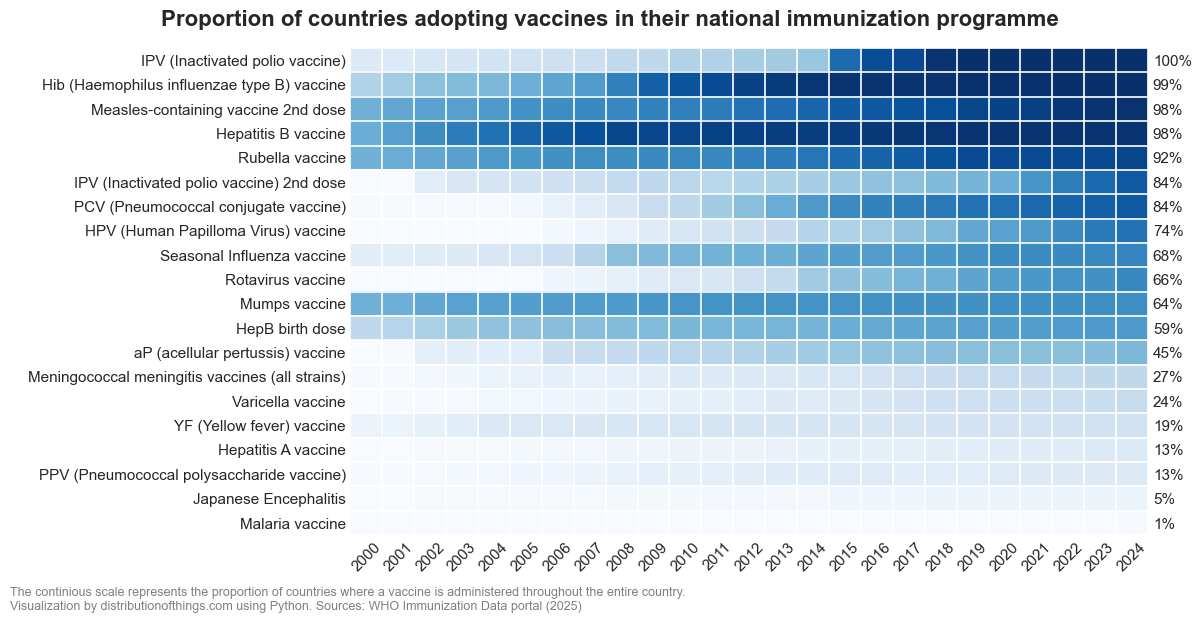

In [86]:
# Create a file path
intro_df = pd.read_excel('./data/vaccine-introduction-data.xlsx')

# Clean & bin
df = intro_df.loc[(intro_df['INTRO'] == "Yes")]
df = df.loc[intro_df['YEAR'].ge(2000)]

# Count each country once per vaccine × block
counts = (df.drop_duplicates(['DESCRIPTION','YEAR','COUNTRYNAME'])
            .groupby(['DESCRIPTION','YEAR'])['COUNTRYNAME']
            .nunique()
            .unstack(fill_value=0)
            .sort_index(key=lambda x: x.str.lower()))

sns.set_theme(style="whitegrid", context="notebook", rc={"axes.grid": False})

# proportions (0–1)
heat = counts.div(194.0).copy()

# ensure numeric, sorted year columns
heat.columns = [int(c) for c in heat.columns]
heat = heat.reindex(sorted(heat.columns), axis=1)

# 2025 column + sort vaccines by 2025 descending
if 2024 not in heat.columns:
    raise KeyError("2025 not in YEAR_BIN columns")
heat = heat.sort_values(by=2024, ascending=False)

labels_right = heat[2024].map(lambda v: f"{v:.0%}")

n_rows, n_cols = heat.shape
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(heat.values, aspect='auto', cmap='Blues', vmin=0, vmax=1)

# ticks/labels
ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(heat.columns, rotation=45, ha='center')
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(heat.index)

# no border, no tick marks
for s in ('top','right','left','bottom'):
    ax.spines[s].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)

# cell-edge lines ONLY over the heatmap
edge_w = 1.2
ax.vlines(np.arange(-0.5, n_cols, 1), -0.5, n_rows-0.5, colors='white', lw=edge_w, zorder=2)
ax.hlines(np.arange(-0.5, n_rows, 1), -0.5, n_cols-0.5, colors='white', lw=edge_w, zorder=2)

# right-hand 2025 % labels
ax_right = ax.twinx()
ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(np.arange(n_rows))
ax_right.set_yticklabels(labels_right)
ax_right.tick_params(axis='y', right=True, labelright=True, length=0)
for s in ('top','right','left','bottom'):
    ax_right.spines[s].set_visible(False)

plt.suptitle('Proportion of countries adopting vaccines in their national immunization programme', fontsize=16, fontweight='bold', y=0.97)
plt.figtext(0.00, -0.03, 'The continious scale represents the proportion of countries where a vaccine is administered throughout the entire country.\n'
            'Visualization by distributionofthings.com using Python. Sources: WHO Immunization Data portal (2025)',
            ha='left', color='gray', fontsize=9)
plt.tight_layout()
plt.savefig(results_path + 'Proportion_of_Countries_Adopting_Routine_Vaccines_(2000–2024).png', dpi=300, bbox_inches='tight')
plt.show()

# Global Vaccination Coverage

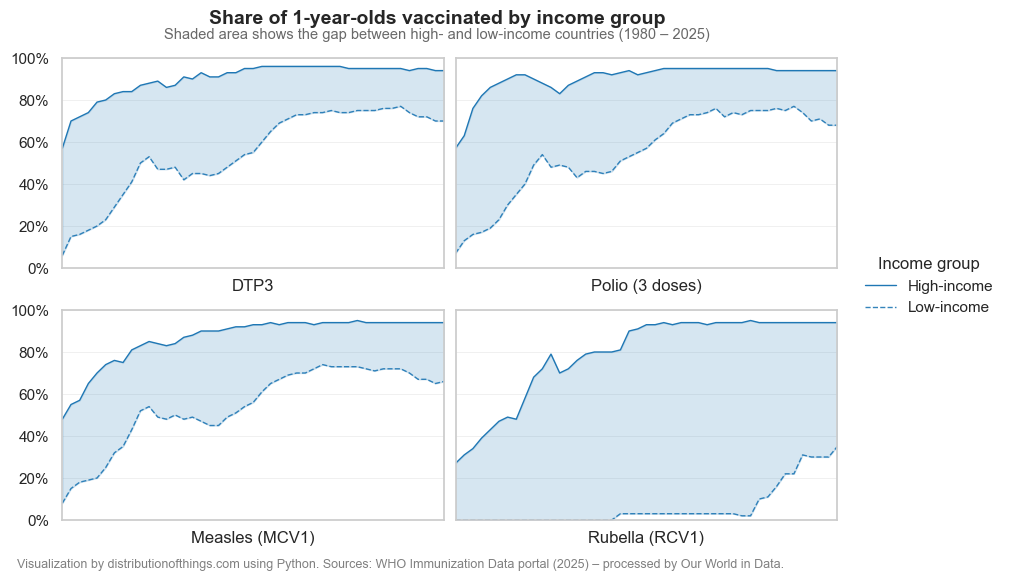

In [82]:
url = "https://ourworldindata.org/grapher/global-vaccination-coverage.csv?v=1&csvType=full&useColumnShortNames=true"
r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
r.raise_for_status()
df = pd.read_csv(io.StringIO(r.text))

df = df[df['Entity'].isin(["High-income countries", "Low-income countries"])].copy()
df['Entity'] = df['Entity'].map({"High-income countries": "High-income",
                                 "Low-income countries": "Low-income"})
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

VAX_COLS = {
    "coverage__antigen_dtpcv3": "DTP3",
    "coverage__antigen_pol3": "Polio (3 doses)",
    "coverage__antigen_mcv1": "Measles (MCV1)",
    "coverage__antigen_rcv1": "Rubella (RCV1)",
}
INCOME_ORDER = ["High-income", "Low-income"]   # <-- list (ordered)

YEAR_MIN = 1980

df_plot = df.copy()
df_plot["Year"] = pd.to_numeric(df_plot["Year"], errors="coerce").astype("Int64")
df_plot = df_plot[df_plot["Year"] >= YEAR_MIN].dropna(subset=["Year"]).copy()
df_plot["Entity"] = pd.Categorical(df_plot["Entity"], categories=INCOME_ORDER, ordered=True)


def plot_vax(ax, y_col, nice_name):
    sub = df_plot[["Entity", "Year", y_col]].dropna(subset=["Entity", y_col]).copy()
    if sub.empty:
        ax.set_title(nice_name + " (no data)", y=-0.30, fontsize=10)
        return None, None

    # proportions 0–1
    if sub[y_col].max() > 1.5:
        sub[y_col] = sub[y_col] / 100.0

    # helper to get aligned series for an entity
    def get_series(entity):
        g = sub[sub["Entity"] == entity].sort_values("Year").copy()
        if g.empty:
            return None, None
        yr_min, yr_max = YEAR_MIN, int(sub["Year"].max())
        g = (g.set_index("Year")
               .reindex(range(yr_min, yr_max + 1))
               .rename_axis("Year")
               .reset_index())
        return g["Year"].to_numpy(), g[y_col].to_numpy()

    years_hi, y_hi = get_series("High-income")
    years_lo, y_lo = get_series("Low-income")

    blue = "tab:blue"

    # plot lines (both blue)
    h_hi = ax.plot(years_hi, y_hi, color=blue, linewidth=1.0, label="High-income")[0]
    h_lo = ax.plot(years_lo, y_lo, color=blue, linewidth=1.0, alpha=0.9, label="Low-income")[0]
    h_lo.set_linestyle("--")

    # shade the difference (blue). Low area stays white.
    if years_hi is not None and years_lo is not None:
        # align arrays (they already share the same year grid)
        mask = np.isfinite(y_hi) & np.isfinite(y_lo)
        top = np.maximum(y_hi[mask], y_lo[mask])
        bot = np.minimum(y_hi[mask], y_lo[mask])
        ax.fill_between(years_hi[mask], bot, top, color=blue, alpha=0.18)

    ax.set_xlim(YEAR_MIN, int(sub["Year"].max()))
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    # tidy: no x ticks, light y-grid
    ax.set_xticks([])
    ax.tick_params(axis="x", which="both", length=0, labelbottom=False)
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.35)
    ax.grid(False, axis="x")

    # put the nice name **below** each subplot
    ax.set_title(nice_name, y=-0.15, fontsize=12)

    # return handles if you still want a legend
    return [h_hi, h_lo], ["High-income", "Low-income"]


fig, axes = plt.subplots(
    2, 2, figsize=(10, 6), sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.03}   # smaller = closer (try 0.02–0.06)
)
axes = axes.ravel()

handles, labels = None, None
for ax, (col, nice_name) in zip(axes, VAX_COLS.items()):
    h, l = plot_vax(ax, col, nice_name)
    if handles is None and h is not None:
        handles, labels = h, l

main_title = "Share of 1-year-olds vaccinated by income group"
subtitle   = "Shaded area shows the gap between high- and low-income countries (1980 – 2025)"

fig.legend(handles=handles, labels=labels, title="Income group", loc="center right", bbox_to_anchor=(1.07, 0.5), frameon=False)

# subtitle (centered under the title)
fig.suptitle(main_title, y=0.96, fontsize=14, fontweight="bold")
fig.text(0.5, 0.93, subtitle, ha="center", va="top", fontsize=10.5, color="dimgray")
plt.figtext(0.08, 0.03, 'Visualization by distributionofthings.com using Python. Sources: WHO Immunization Data portal (2025) – processed by Our World in Data.',
            ha='left', color='gray', fontsize=9)
plt.savefig(results_path + 'Share_1-year-olds_vaccinated_income_group.png', dpi=300, bbox_inches='tight')
plt.show()

## Vaccine development

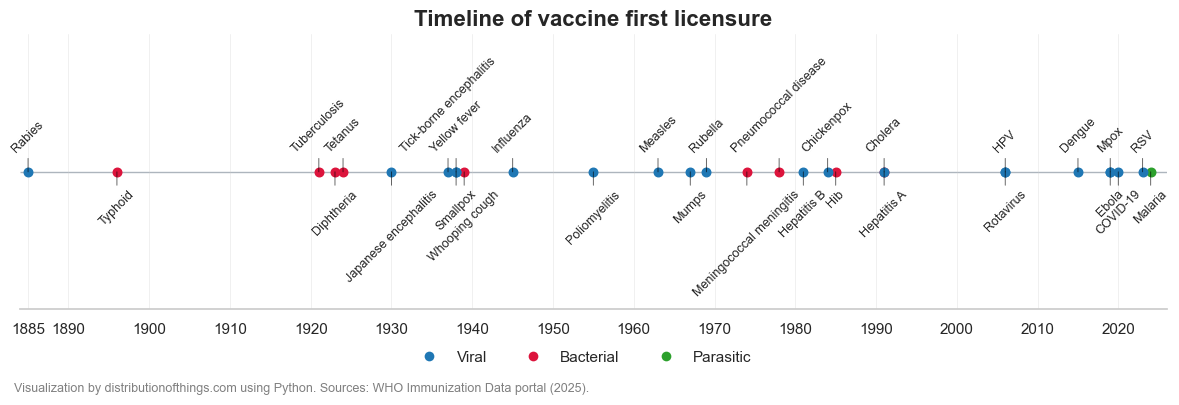

In [10]:
pd.options.display.float_format = '{:.0f}'.format
v = pd.read_excel('./data/available_pipeline_vaccines copy.xlsx')
v["Year"] = v["Licensure"].astype(str).str.extract(r"(\d{4})")[0].astype("Int64")
v = v.dropna(subset=["Pathogen", "Year"]).copy()
v["Year"] = v["Year"].astype(int)
v["Label"] = v["Disease"]

# Sort chronologically (ties by Disease) and alternate labels up/down globally
v = v.sort_values(["Year", "Disease"]).reset_index(drop=True)
v["alt_sign"] = np.where(v.index % 2 == 0, 1, -1)
label_dy  = 0.05
line_frac = 1
v["y_txt"] = v["alt_sign"] * label_dy

# --- Colors for classes present ---
colors = {"Viral": "#1f77b4", "Bacterial": "crimson", "Parasitic": "#2ca02c"}

# --- Axis bounds & ticks ---
xmin, xmax = 1884, 2026           # start at 1885
ticks = np.r_[1885, np.arange(1890, xmax + 1, 10)]

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 4))

# Baseline timeline
ax.hlines(0, xmin, xmax, color="#adb5bd", linewidth=1.0, zorder=0)

# Dots colored by pathogen class
for cls, sub in v.groupby("Pathogen"):
    ax.scatter(sub["Year"], np.zeros(len(sub)), s=38,
               color=colors.get(cls, "gray"), zorder=2, label=cls)

label_offset_pts = 12
stem_lw = 0.7

# Leader lines + alternating labels
for _, r in v.iterrows():
    up = r["alt_sign"] > 0
    angle  = 45
    valign = "bottom" if up else "top"
    dy = label_offset_pts if up else -label_offset_pts

    ax.annotate(
        r["Label"],
        xy=(r["Year"], 0),                 # dot position
        xytext=(0, dy),                    # offset in *points*
        textcoords="offset points",
        ha="center", va=valign, rotation=angle, fontsize=9,
        arrowprops=dict(arrowstyle='-', lw=stem_lw, color='black', alpha=0.6,
                        shrinkA=0, shrinkB=0),   # short straight leader
        zorder=3
    )

# Axes formatting
ax.set_xlim(xmin, xmax)
ax.set_xticks(ticks)
ax.set_yticks([])  # hide y-axis
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)

# Light vertical grid
ax.grid(True, axis="x", linewidth=0.6, alpha=0.35)
ax.grid(False, axis="y")

# legend for pathogen type (only classes present)
present = v["Pathogen"].unique().tolist()
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='none',
           markerfacecolor=colors.get(k, "gray"), markeredgecolor="none",
           markersize=7, label=k)
    for k in ["Viral", "Bacterial", "Parasitic"] if k in present
]
ax.legend(handles=legend_handles, ncols=3, bbox_to_anchor=(0.65, -0.1), frameon=False)

ax.set_title("Timeline of vaccine first licensure", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.figtext(0.02, 0, 'Visualization by distributionofthings.com using Python. Sources: WHO Immunization Data portal (2025).',
            ha='left', color='gray', fontsize=9)
plt.savefig(results_path + "vaccine_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

## Disease Eradication: Smallpox

Louis Pasteur once said that “it is within the power of man to eradicate infection from the earth”. That power has so far eradicated two infectious diseases: smallpox and rinderpest.

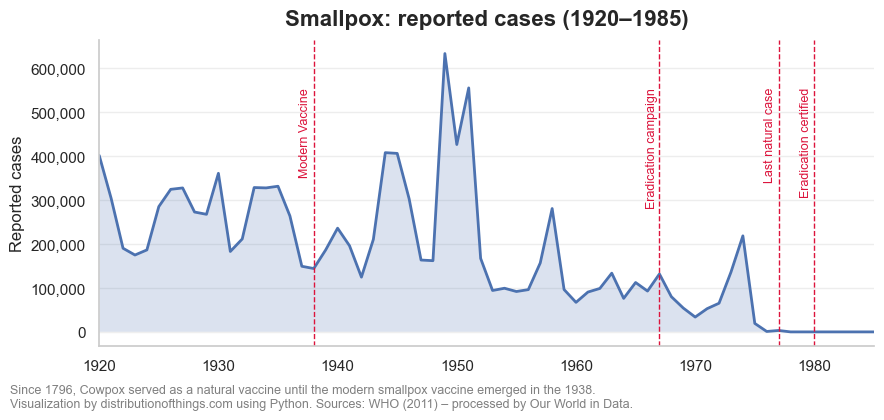

In [12]:
# Smallpox
url = "https://ourworldindata.org/grapher/global-smallpox-cases.csv?v=1&csvType=full&useColumnShortNames=true"
r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
r.raise_for_status()
s = pd.read_csv(io.StringIO(r.text))
s = s.rename(columns={'reported_smallpox_cases': 'Smallpox cases'})

def fmt_thousands(x, _):
    return f"{int(x):,}"

# Use your existing `s` DataFrame; keep only the World series
d = (s[s["Entity"].eq("World")] if "Entity" in s.columns else s)[["Year", "Smallpox cases"]]
d = d.dropna().sort_values("Year").copy()

fig, ax = plt.subplots(figsize=(9, 4))

# line + soft fill
ax.plot(d["Year"], d["Smallpox cases"], lw=2.0)
ax.fill_between(d["Year"], 0, d["Smallpox cases"], alpha=0.2)

# markers
markers = [
    (1938, "Modern Vaccine"),
    (1967, "Eradication campaign"),
    (1977, "Last natural case"),
    (1980, "Eradication certified"),
]
ymax = d["Smallpox cases"].max()
for yr, lbl in markers:
    ax.axvline(yr, ls="--", lw=1, color="crimson")
    ax.text(yr - 1.2, ymax * 0.88, lbl, color="crimson",
            fontsize=9, rotation=90, va="top")

# axes, grid, title
ax.set_xlim(1920, 1985)
ax.set_ylabel("Reported cases")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_thousands))
ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
ax.grid(True, axis="y", alpha=0.35)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax.set_title("Smallpox: reported cases (1920–1985)", y=1.02, fontsize=16, fontweight='bold')
plt.figtext(0.02, -0.04, 'Since 1796, Cowpox served as a natural vaccine until the modern smallpox vaccine emerged in the 1938.\n'
            'Visualization by distributionofthings.com using Python. Sources: WHO (2011) – processed by Our World in Data.',
            ha='left', color='gray', fontsize=9)
fig.tight_layout()
plt.savefig(results_path + "small_pox_timeline.png", dpi=300, bbox_inches="tight")
plt.show()


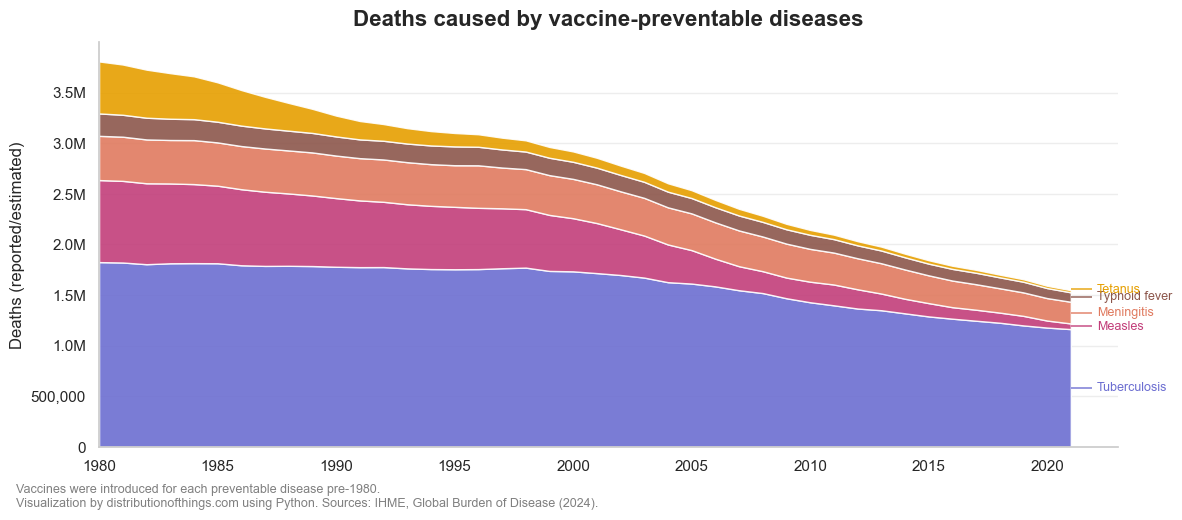

In [13]:
d = pd.read_csv('./data/IHME-GBD_2021_DATA-2423a0d3-1.csv')
drop_causes = ['Malaria','Cervical cancer','Diphtheria','Yellow fever','Dengue','Rabies', 'Acute hepatitis B']
d = d.loc[~d['cause'].isin(drop_causes)].copy()

wide = (d.pivot_table(index="year", columns="cause", values="val", aggfunc="sum")
          .sort_index()
          .fillna(0))
wide.index.name = "year"

order = wide.sum().sort_values(ascending=False).index.tolist()

# Colors
palette = {
    "Tuberculosis":     "#6C6ED1",
    "Typhoid fever":    "#8C564B",
    "Meningitis":       "#E07A5F",
    "Tetanus":          "#E69F00",
    "Measles":          "#C23E7A",
}
colors = [palette.get(c, None) for c in order]

fig, ax = plt.subplots(figsize=(12, 5))

# Stacked area
ax.stackplot(
    wide.index,
    *[wide[c].to_numpy() for c in order],
    labels=order,
    colors=colors,
    alpha=0.9
)

# Right-side annotations
last_year = wide.index.max()
first_year = wide.index.min()
xpad = max(2, int((last_year - first_year) * 0.05))
ax.set_xlim(first_year, last_year + xpad)

# Heights of each layer at the last year
h_last = np.array([wide[c].iloc[-1] for c in order], dtype=float)
h_last = np.nan_to_num(h_last, nan=0.0)

# Cumulative bottoms/tops then midpoints
cum = np.cumsum(h_last)
bottoms = cum - h_last
ymid = bottoms + h_last / 2.0

# De-overlap labels with a simple vertical dodge
total = wide.sum(axis=1)
ymin, ymax = 0.0, max(total.max(), 1.0)
min_gap = 0.02 * (ymax - ymin)  # 2% of range
idx = np.argsort(ymid)
ym = ymid[idx]
names_sorted = [order[i] for i in idx]
cols_sorted  = [palette.get(n, "black") for n in names_sorted]

for i in range(1, len(ym)):
    if ym[i] - ym[i-1] < min_gap:
        ym[i] = ym[i-1] + min_gap
ym = np.clip(ym, ymin + 1e-6, ymax - 1e-6)

# Draw short colored leader lines + labels
x0 = last_year
x1 = last_year + xpad * 0.45  # line end
x_text = last_year + xpad * 0.55
for y, name, col in zip(ym, names_sorted, cols_sorted):
    ax.hlines(y, x0, x1, colors=col, lw=1.1, alpha=0.9)
    ax.text(x_text, y, name, va="center", ha="left", color=col, fontsize=9)

# Formatting
ax.set_ylabel("Deaths (reported/estimated)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _:
                                           f"{x/1_000_000:.1f}M" if x >= 1e6 else f"{int(x):,}"))
ax.grid(True, axis="y", alpha=0.35)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

ax.set_title("Deaths caused by vaccine-preventable diseases", y=1.02, fontsize=16, fontweight='bold')
plt.figtext(0.02, -0.03, 'Vaccines were introduced for each preventable disease pre-1980.\n'
            'Visualization by distributionofthings.com using Python. Sources: IHME, Global Burden of Disease (2024).',
            ha='left', color='gray', fontsize=9)

plt.tight_layout()
plt.savefig(results_path + "deaths_cased_vaccine_preventable_prexist_vax.png", dpi=300, bbox_inches="tight")
plt.show()


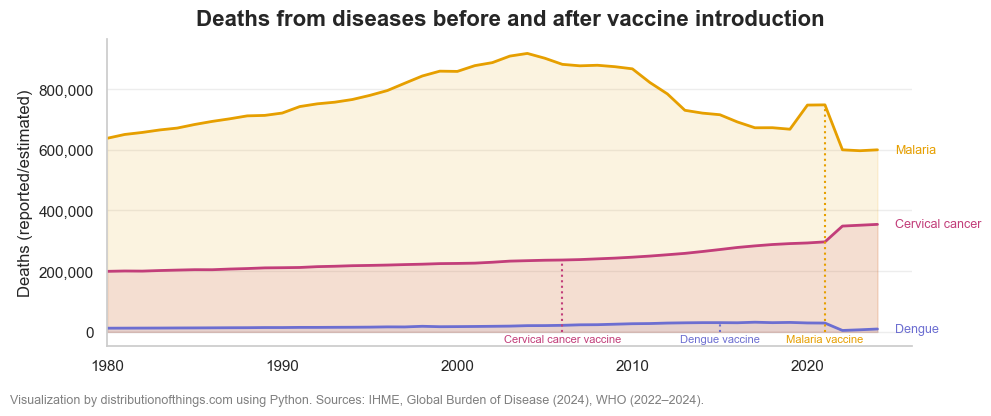

In [14]:
d = pd.read_csv('./data/IHME-GBD_2021_DATA-2423a0d3-1.csv') 
keep = ['Malaria','Cervical cancer', 'Tuberculosis', 'Dengue'] 
d = d.loc[d['cause'].isin(keep)].copy() 
wide = (d.pivot_table(index="year", columns="cause", values="val", aggfunc="sum").sort_index().fillna(0)) 
wide.index.name = "year"

# Official + estimated updates
rows = [
    # disease, year, value, is_est
    ("Malaria",          2022, 600_000, False),
    ("Malaria",          2023, 597_000, False),
    ("Malaria",          2024, 600_000, True),     # flat placeholder

    ("Dengue",           2022,   4_700,  True),    # back-cast estimate (see note)
    ("Dengue",           2023,   6_892,  False),
    ("Dengue",           2024,   9_508,  False),

    ("Cervical cancer",  2022, 348_709,  False),
    ("Cervical cancer",  2023, 351_500,  True),    # pop-scaled
    ("Cervical cancer",  2024, 354_300,  True),
]
upd = pd.DataFrame(rows, columns=["cause","year","val","is_est"])

# Pivot & merge
patch = upd.pivot(index="year", columns="cause", values="val")
estmask = upd.pivot(index="year", columns="cause", values="is_est").fillna(False)

# add/overwrite values
wide = wide.combine_first(patch)
wide.update(patch)

# Keep an 'is_estimate' table in parallel (same index/columns as wide)
is_estimate = pd.DataFrame(False, index=wide.index, columns=wide.columns)
is_estimate.update(estmask.fillna(False))


# 3) Plot overlay (area + line) + vaccine-intro markers
palette = {
    "Malaria":          "#E69F00",
    "Cervical cancer":  "#C23E7A",
    "Dengue":           "#6C6ED1",
}
def col(c): return palette.get(c, None)

fig, ax = plt.subplots(figsize=(10, 4))
order = [c for c in wide.columns if c in ["Malaria","Cervical cancer","Dengue"]]

for name in order:
    y = wide[name]
    ax.fill_between(wide.index, 0, y, alpha=0.12, color=col(name))
    ax.plot(wide.index, y, lw=2.0, color=col(name), label=name)

# Right-side labels at last available value
last_x = int(wide.index.max())
ax.set_xlim(int(wide.index.min()), last_x + 2)
for name in order:
    s = wide[name].dropna()
    if not s.empty:
        ax.text(last_x + 1, s.iloc[-1], name, va="center", fontsize=9, color=col(name) or "black")

# Vaccine-introduced markers (as you wanted)
vaccine_year = {
    "Malaria":         2021,  # WHO policy milestone; change if you prefer first licensure
    "Cervical cancer": 2006,  # HPV vaccine first approvals
    "Dengue":          2015,  # first licensure (Dengvaxia, Mexico)
}
for name, vx in vaccine_year.items():
    if name in wide.columns:
        # vertical dotted line in series color, label it
        # interpolate to find the series height at vx (for label placement)
        ser = wide[name].astype(float)
        xs, ys = ser.index.to_numpy(dtype=float), ser.to_numpy(dtype=float)
        mask = ~np.isnan(ys)
        if mask.sum() >= 2 and xs[mask].min() <= vx <= xs[mask].max():
            y_at = np.interp(vx, xs[mask], ys[mask])
        else:
            y_at = np.nanmax(ys) * 0.15 if np.isfinite(np.nanmax(ys)) else 0
        ax.vlines(vx, 0, y_at, colors=col(name), linestyles="dotted", lw=1.5)
        ax.text(vx, 0.04, f"{name} vaccine",
                transform=ax.get_xaxis_transform(),
                ha="center", va="top",
                color=col(name), fontsize=8,
                clip_on=False
               )


# Formatting
ax.set_ylabel("Deaths (reported/estimated)")
fmtM = lambda x, _: f"{x/1_000_000:.1f} million" if x >= 1_000_000 else f"{int(x):,}"
ax.yaxis.set_major_formatter(FuncFormatter(fmtM))
ax.grid(True, axis="y", alpha=0.35)
for s in ("top","right"): ax.spines[s].set_visible(False)
ax.set_title("Deaths from diseases before and after vaccine introduction",
             loc="center", fontsize=16, fontweight="bold",  y=1.02)

fig.text(0.01, -0.03,
         "Visualization by distributionofthings.com using Python. Sources: IHME, Global Burden of Disease (2024), WHO (2022–2024).",
         fontsize=9, color="gray")
fig.tight_layout()
plt.savefig(results_path + "deaths_cased_vaccine_preventable_new_vax.png", dpi=300, bbox_inches="tight")
plt.show()
